# Módulo 1 — Clasificador de Productos
**EfficientNet-B0** con transfer learning sobre Fashion Product Images (Kaggle)

> Activar GPU: Runtime → Change runtime type → T4 GPU

In [2]:
# Montar Drive y configurar rutas
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/smartretail360'
DATA_DIR   = f'{DRIVE_ROOT}/data'
MODEL_DIR  = f'{DRIVE_ROOT}/models/image_classifier'

import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [4]:
!pip install -q tensorflow Pillow scikit-learn tqdm kaggle

In [ ]:
# Descargar dataset (requiere kaggle.json en /root/.kaggle/)
# !pip install -q kaggle
# !mkdir -p ~/.kaggle && cp /content/drive/MyDrive/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d paramaggarwal/fashion-product-images-small -p {DATA_DIR} --unzip

sys:1: UserWarning: CSV malformed: expected 720 rows, actual 2778 rows, in chunk starting at byte offset 1211387, length 270732


(44446, 10)
Filas tras filtrar a 3 clases: 41911


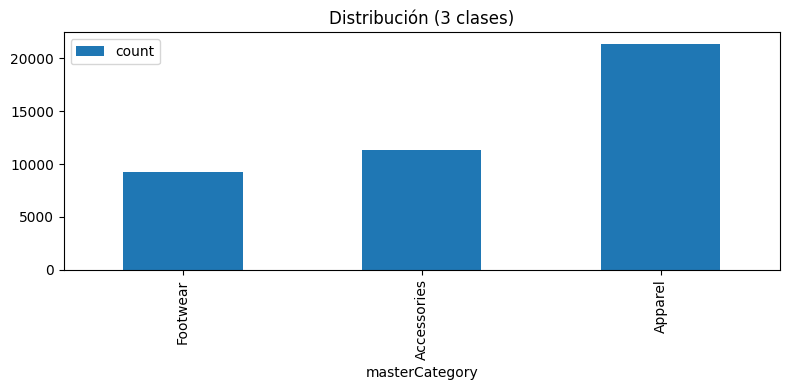

In [5]:
# EDA rápido
import polars as pl
import matplotlib.pyplot as plt

DATASET_DIR = f'{DATA_DIR}/external/fashion_products'
IMAGES_DIR = f'{DATASET_DIR}/images'

styles = pl.read_csv(f'{DATASET_DIR}/styles.csv', ignore_errors=True, truncate_ragged_lines=True)
print(styles.shape)

VALID_CLASSES = ["Apparel", "Footwear", "Accessories"]
styles = styles.filter(pl.col('masterCategory').is_in(VALID_CLASSES))
print(f"Filas tras filtrar a 3 clases: {styles.shape[0]}")

styles['masterCategory'].value_counts().to_pandas().plot(
    kind='bar', x='masterCategory', y='count', figsize=(8,4), title='Distribución (3 clases)'
)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: preparar splits train/val con image_dataset_from_directory
# TODO: instanciar build_model() desde src/image_classifier/model_efficientnet.py
# TODO: Fase 1 — entrenar solo cabeza (freeze_backbone=True, ~10 épocas)
# TODO: Fase 2 — fine-tuning completo (freeze_backbone=False, ~10 épocas, lr=1e-4)
# TODO: model.save(f'{MODEL_DIR}/efficientnet_b0.keras')
print('Celdas de entrenamiento pendientes — completar en semana 2-3')

In [ ]:
# Evaluación final
# from sklearn.metrics import classification_report, confusion_matrix
# TODO: inferencia sobre test set
# TODO: imprimir classification_report
# TODO: graficar confusion matrix con seaborn